In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import os

print(os.getcwd())

e:\MA_Target_Screening_ML\notebook


In [3]:
df = pd.read_excel('data/all_data.xlsx')

In [4]:
df.head()

,Unnamed: 0,Instrument,AD-250,AD-60,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
0,0,COR,2021-03-10,2021-09-16,2021-10-16,2021-11-15,40.21891,79309000.0,1.788389e+09,22.855325,...,39.991626,5543000.0,1,0.044347,0.005647,0.003099,51.388454,0.214218,-0.858267,8.048231
1,1,DVD,2021-03-04,2021-09-10,2021-10-10,2021-11-09,26.66113,7482000.0,6.902700e+07,25.492173,...,-0.345537,12568000.0,1,0.108392,0.031004,0.182074,12.643395,0.000000,-11.662717,-5.932295
2,2,MCFE.O,2021-03-03,2021-09-09,2021-10-09,2021-11-08,62.31934,-118000000.0,2.187000e+09,10.883691,...,8.768888,231000000.0,1,-0.053955,0.247075,0.105624,28.844474,0.194682,-12.960495,11.902193
3,3,CPLG.K,2021-03-03,2021-09-09,2021-10-09,2021-11-08,-10.70560,-178000000.0,1.682000e+09,-30.140187,...,11.758621,143000000.0,1,-0.105826,-0.150852,0.085018,-116.996230,0.587626,12.219687,-17.358218
4,4,MNR,2021-02-28,2021-09-06,2021-10-06,2021-11-05,81.96786,-22143000.0,1.912112e+09,49.471649,...,8.678789,23517000.0,1,-0.011580,-0.491178,0.012299,39.203266,0.262022,-0.604319,13.026745


In [5]:
df_cleaned = df.iloc[:,2:]


In [6]:
df_cleaned.head()

,AD-250,AD-60,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
0,2021-03-10,2021-09-16,2021-10-16,2021-11-15,40.21891,79309000.0,1.788389e+09,22.855325,3427000.0,6.068240e+08,...,39.991626,5543000.0,1,0.044347,0.005647,0.003099,51.388454,0.214218,-0.858267,8.048231
1,2021-03-04,2021-09-10,2021-10-10,2021-11-09,26.66113,7482000.0,6.902700e+07,25.492173,1195000.0,3.854300e+07,...,-0.345537,12568000.0,1,0.108392,0.031004,0.182074,12.643395,0.000000,-11.662717,-5.932295
2,2021-03-03,2021-09-09,2021-10-09,2021-11-08,62.31934,-118000000.0,2.187000e+09,10.883691,718000000.0,2.906000e+09,...,8.768888,231000000.0,1,-0.053955,0.247075,0.105624,28.844474,0.194682,-12.960495,11.902193
3,2021-03-03,2021-09-09,2021-10-09,2021-11-08,-10.70560,-178000000.0,1.682000e+09,-30.140187,-62000000.0,4.110000e+08,...,11.758621,143000000.0,1,-0.105826,-0.150852,0.085018,-116.996230,0.587626,12.219687,-17.358218
4,2021-02-28,2021-09-06,2021-10-06,2021-11-05,81.96786,-22143000.0,1.912112e+09,49.471649,-82428000.0,1.678170e+08,...,8.678789,23517000.0,1,-0.011580,-0.491178,0.012299,39.203266,0.262022,-0.604319,13.026745


In [7]:
data = df_cleaned.drop(columns=['AD-250','AD-60','AD-30','AD'])

In [8]:
data.head()

,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,Revenue from Business Activities - Total.1,Revenue from Business Activities - Total.2,Revenue from Business Activities - Total.3,Current Ratio,...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
0,40.21891,79309000.0,1.788389e+09,22.855325,3427000.0,6.068240e+08,5.727270e+08,5.443920e+08,4.818210e+08,0.39338,...,39.991626,5543000.0,1,0.044347,0.005647,0.003099,51.388454,0.214218,-0.858267,8.048231
1,26.66113,7482000.0,6.902700e+07,25.492173,1195000.0,3.854300e+07,4.596300e+07,4.701600e+07,4.674200e+07,3.47706,...,-0.345537,12568000.0,1,0.108392,0.031004,0.182074,12.643395,0.000000,-11.662717,-5.932295
2,62.31934,-118000000.0,2.187000e+09,10.883691,718000000.0,2.906000e+09,2.635000e+09,2.409000e+09,2.076000e+09,0.38323,...,8.768888,231000000.0,1,-0.053955,0.247075,0.105624,28.844474,0.194682,-12.960495,11.902193
3,-10.70560,-178000000.0,1.682000e+09,-30.140187,-62000000.0,4.110000e+08,8.120000e+08,8.620000e+08,8.360000e+08,4.58824,...,11.758621,143000000.0,1,-0.105826,-0.150852,0.085018,-116.996230,0.587626,12.219687,-17.358218
4,81.96786,-22143000.0,1.912112e+09,49.471649,-82428000.0,1.678170e+08,1.548210e+08,1.356950e+08,1.163853e+08,11.51610,...,8.678789,23517000.0,1,-0.011580,-0.491178,0.012299,39.203266,0.262022,-0.604319,13.026745


In [9]:
X =data.drop(columns=['Label','AR'])

In [10]:
y=data['Label']

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3830 entries, 0 to 3829
Data columns (total 24 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Gross Profit Margin - %                                      3830 non-null   float64
 1   Net Income after Minority Interest                           3830 non-null   float64
 2   Total Capital                                                3830 non-null   float64
 3   Operating Margin - %, TTM                                    3830 non-null   float64
 4   Free Cash Flow                                               3830 non-null   float64
 5   Revenue from Business Activities - Total                     3830 non-null   float64
 6   Revenue from Business Activities - Total.1                   3830 non-null   float64
 7   Revenue from Business Activities - Total.2                   3830 non-null   f

In [12]:
X

,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,Revenue from Business Activities - Total.1,Revenue from Business Activities - Total.2,Revenue from Business Activities - Total.3,Current Ratio,...,Total Shareholders' Equity incl Minority Intr & Hybrid Debt,Debt - Total,Net Debt per Share,Cash & Cash Equivalents - Total,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,Sales_growth
0,40.21891,79309000.0,1.788389e+09,22.855325,3427000.0,6.068240e+08,5.727270e+08,5.443920e+08,4.818210e+08,0.39338,...,7.247800e+07,1.715911e+09,39.991626,5543000.0,0.044347,0.005647,0.003099,51.388454,0.214218,8.048231
1,26.66113,7482000.0,6.902700e+07,25.492173,1195000.0,3.854300e+07,4.596300e+07,4.701600e+07,4.674200e+07,3.47706,...,6.902700e+07,0.000000e+00,-0.345537,12568000.0,0.108392,0.031004,0.182074,12.643395,0.000000,-5.932295
2,62.31934,-118000000.0,2.187000e+09,10.883691,718000000.0,2.906000e+09,2.635000e+09,2.409000e+09,2.076000e+09,0.38323,...,-1.800000e+09,3.987000e+09,8.768888,231000000.0,-0.053955,0.247075,0.105624,28.844474,0.194682,11.902193
3,-10.70560,-178000000.0,1.682000e+09,-30.140187,-62000000.0,4.110000e+08,8.120000e+08,8.620000e+08,8.360000e+08,4.58824,...,8.570000e+08,8.250000e+08,11.758621,143000000.0,-0.105826,-0.150852,0.085018,-116.996230,0.587626,-17.358218
4,81.96786,-22143000.0,1.912112e+09,49.471649,-82428000.0,1.678170e+08,1.548210e+08,1.356950e+08,1.163853e+08,11.51610,...,1.037605e+09,8.745070e+08,8.678789,23517000.0,-0.011580,-0.491178,0.012299,39.203266,0.262022,13.026745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3825,62.42993,541100000.0,4.367400e+09,11.726687,350300000.0,4.424000e+09,4.424000e+09,4.442100e+09,4.169800e+09,3.99371,...,3.335400e+09,1.032000e+09,1.297855,874700000.0,0.123895,0.079182,0.200279,16.059410,0.064760,2.040941
3826,23.79594,-87714000.0,5.096310e+08,-3.811498,-75385000.0,1.641482e+09,1.641482e+09,1.641482e+09,1.651187e+09,2.77924,...,2.545250e+08,2.551060e+08,8.456775,15830000.0,-0.172113,-0.045925,0.031062,-177.648132,0.750663,-0.195920
3827,37.47708,-213833000.0,1.223547e+09,-9.737199,114852000.0,1.390674e+09,1.390674e+09,1.322417e+09,1.327029e+09,1.28451,...,5.663600e+08,6.571870e+08,2.901731,296353000.0,-0.174765,0.082587,0.242208,7.314333,0.684461,1.604663
3828,100.00000,-6600000.0,2.791600e+09,7.076690,76400000.0,1.623000e+09,1.623000e+09,1.558200e+09,1.507600e+09,0.62958,...,9.234000e+08,1.868200e+09,20.687124,12500000.0,-0.002364,0.047073,0.004478,11.827823,0.413914,2.504991


In [13]:
y

0       1
1       1
2       1
3       1
4       1
       ..
3825    0
3826    0
3827    0
3828    0
3829    0
Name: Label, Length: 3830, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3064, 24), (766, 24), (3064,), (766,))

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(class_weight="balanced")

In [57]:
from sklearn.model_selection import GridSearchCV
parameter = {'penalty':['l2'], 'C':[1,2,3,4,5,6,10,20,30,40,50], 'max_iter':[500,1000,2000]}

In [60]:
lr = LogisticRegression(class_weight='balanced')
lr_param_grid = {    'penalty': ['l2'],'C': [0.1, 1, 3, 10, 30, 50],'max_iter': [1000]}
lr_search = GridSearchCV(lr, param_grid=lr_param_grid, scoring='roc_auc', cv=5)
lr_search.fit(X_train_scaled, y_train)
print(lr_search.best_params_)
print(f"Best CV ROC-AUC: {lr_search.best_score_:.4f}")

{'C': 50, 'max_iter': 1000, 'penalty': 'l2'}
Best CV ROC-AUC: 0.5981


In [61]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_lr = lr_search.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.39      0.55       726
           1       0.06      0.72      0.11        40

    accuracy                           0.40       766
   macro avg       0.51      0.56      0.33       766
weighted avg       0.92      0.40      0.53       766

[[281 445]
 [ 11  29]]


In [49]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf_model = RandomForestClassifier(    n_estimators=200,    max_depth=6,                min_samples_leaf=5,    class_weight='balanced',    random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       726
           1       0.09      0.42      0.14        40

    accuracy                           0.74       766
   macro avg       0.52      0.59      0.49       766
weighted avg       0.91      0.74      0.81       766



In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(confusion_matrix(y_test, y_pred_rf))
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")

[[547 179]
 [ 23  17]]
Precision: 0.087
Recall: 0.425
F1-score: 0.144


In [64]:
from sklearn.metrics import roc_auc_score
lr_prob = lr_search.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
score_lr = roc_auc_score(y_test, lr_prob)
score_rf = roc_auc_score(y_test, rf_prob)
print(f"Logistic Regression ROC-AUC: {score_lr:.4f}")
print(f"Random Forest ROC-AUC:       {score_rf:.4f}")

Logistic Regression ROC-AUC: 0.5915
Random Forest ROC-AUC:       0.6500


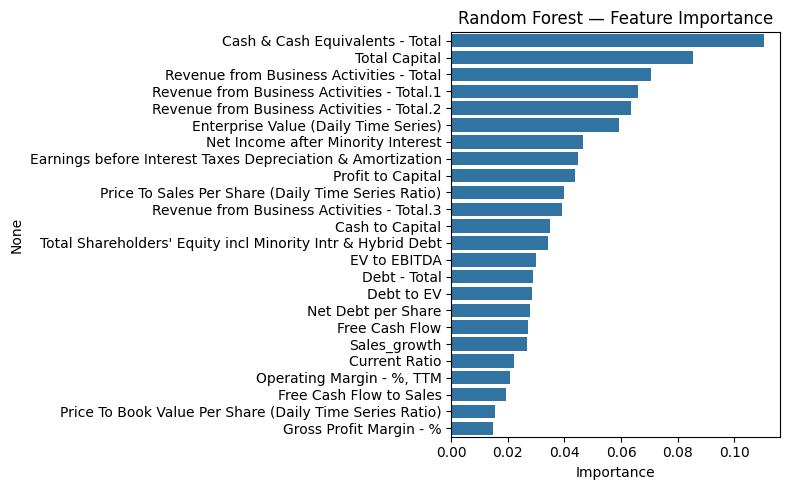

Cash & Cash Equivalents - Total                                0.110636
Total Capital                                                  0.085349
Revenue from Business Activities - Total                       0.070737
Revenue from Business Activities - Total.1                     0.066045
Revenue from Business Activities - Total.2                     0.063386
Enterprise Value (Daily Time Series)                           0.059420
Net Income after Minority Interest                             0.046708
Earnings before Interest Taxes Depreciation & Amortization     0.044737
Profit to Capital                                              0.043825
Price To Sales Per Share (Daily Time Series Ratio)             0.039718
Revenue from Business Activities - Total.3                     0.039192
Cash to Capital                                                0.034960
Total Shareholders' Equity incl Minority Intr & Hybrid Debt    0.034263
EV to EBITDA                                                   0

In [65]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances

In [113]:
df_target = pd.read_excel('data/target_data (1).xlsx')

In [114]:
df_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 28 columns):
 #   Column                                                       Non-Null Count  Dtype         
---  ------                                                       --------------  -----         
 0   Unnamed: 0                                                   209 non-null    int64         
 1   Instrument                                                   209 non-null    object        
 2   AD-30                                                        209 non-null    datetime64[ns]
 3   AD                                                           209 non-null    datetime64[ns]
 4   Gross Profit Margin - %                                      209 non-null    float64       
 5   Net Income after Minority Interest                           209 non-null    int64         
 6   Total Capital                                                209 non-null    int64         
 7   Operating Margin 

In [115]:
df_target.head()

,Unnamed: 0,Instrument,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,...,Total Shareholders' Equity incl Minority Intr & Hybrid Debt,Debt - Total,Net Debt per Share,Cash & Cash Equivalents - Total,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,Sales_growth
0,1,COR,2021-10-16,2021-11-15,40.21891,79309000,1788389000,22.855325,3427000,606824000,...,72478000,1715911000,39.991626,5543000,0.044347,0.005647,0.003099,51.388454,0.214218,8.048231
1,2,CSPR.K,2021-10-16,2021-11-15,51.08350,-89555000,91013000,-10.707998,-63503000,497000000,...,25467000,65546000,-0.576630,88922000,NaN,NaN,NaN,NaN,NaN,NaN
2,3,DVD,2021-10-10,2021-11-09,26.66113,7482000,69027000,25.492173,1195000,38543000,...,69027000,0,-0.345537,12568000,0.108392,0.031004,0.182074,12.643395,0.000000,-5.932295
3,4,MCFE.O,2021-10-09,2021-11-08,62.31934,-118000000,2187000000,10.883691,718000000,2906000000,...,-1800000000,3987000000,8.768888,231000000,-0.053955,0.247075,0.105624,28.844474,0.194682,11.902193
4,5,CPLG.K,2021-10-09,2021-11-08,-10.70560,-178000000,1682000000,-30.140187,-62000000,411000000,...,857000000,825000000,11.758621,143000000,-0.105826,-0.150852,0.085018,-116.996230,0.587626,-17.358218


In [116]:
df_target = df_target.dropna()

print(df_target.shape)
print(df_target.isnull().sum().sum())

(206, 28)
0


In [117]:
df_cleaned_target = df_target.iloc[:,4:]

In [118]:
df_cleaned_target.head()

,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,Revenue from Business Activities - Total.1,Revenue from Business Activities - Total.2,Revenue from Business Activities - Total.3,Current Ratio,...,Total Shareholders' Equity incl Minority Intr & Hybrid Debt,Debt - Total,Net Debt per Share,Cash & Cash Equivalents - Total,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,Sales_growth
0,40.21891,79309000,1788389000,22.855325,3427000,606824000,572727000,544392000,4.818210e+08,0.39338,...,72478000,1715911000,39.991626,5543000,0.044347,0.005647,0.003099,51.388454,0.214218,8.048231
2,26.66113,7482000,69027000,25.492173,1195000,38543000,45963000,47016000,4.674200e+07,3.47706,...,69027000,0,-0.345537,12568000,0.108392,0.031004,0.182074,12.643395,0.000000,-5.932295
3,62.31934,-118000000,2187000000,10.883691,718000000,2906000000,2635000000,2409000000,2.076000e+09,0.38323,...,-1800000000,3987000000,8.768888,231000000,-0.053955,0.247075,0.105624,28.844474,0.194682,11.902193
4,-10.70560,-178000000,1682000000,-30.140187,-62000000,411000000,812000000,862000000,8.360000e+08,4.58824,...,857000000,825000000,11.758621,143000000,-0.105826,-0.150852,0.085018,-116.996230,0.587626,-17.358218
5,81.94939,-22143000,1912112000,49.454326,-82396000,167817000,154821000,135695000,1.163853e+08,11.51610,...,1037605000,874507000,8.678789,23517000,-0.011580,-0.491178,0.012299,39.203266,0.262022,13.026745


In [100]:
df_cleaned_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 24 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Gross Profit Margin - %                                      209 non-null    float64
 1   Net Income after Minority Interest                           209 non-null    int64  
 2   Total Capital                                                209 non-null    int64  
 3   Operating Margin - %, TTM                                    209 non-null    float64
 4   Free Cash Flow                                               209 non-null    int64  
 5   Revenue from Business Activities - Total                     209 non-null    int64  
 6   Revenue from Business Activities - Total.1                   209 non-null    int64  
 7   Revenue from Business Activities - Total.2                   209 non-null    int

In [119]:
print("X shape:", X.shape)
print("Target shape:", df_cleaned_target.shape)

print("\nColumns in X but not Target:")
print(set(X.columns) - set(df_target.columns))

print("\nColumns in Target but not X:")
print(set(df_cleaned_target.columns) - set(X.columns))

print("\nSame order?")
print(X.columns.equals(df_target.columns))

X shape: (3830, 24)
Target shape: (206, 24)

Columns in X but not Target:
set()

Columns in Target but not X:
set()

Same order?
False


In [120]:
rf_target_prob = rf_model.predict_proba(df_cleaned_target)[:, 1]
print(rf_target_prob)

[0.00469574 0.01918941 0.0683453  0.05517304 0.02214987 0.0412047
 0.05468238 0.04062424 0.02499991 0.04494794 0.07042035 0.06130085
 0.02499991 0.05491553 0.04062424 0.10815314 0.01563964 0.03689596
 0.07576237 0.04948473 0.00758766 0.05140007 0.02499991 0.05140007
 0.0412047  0.0669663  0.03649401 0.01202688 0.02499991 0.03649401
 0.01190206 0.01947479 0.04122603 0.05140007 0.00758766 0.01585222
 0.0427391  0.0337025  0.01947479 0.03689596 0.03649401 0.05601085
 0.05140007 0.05584382 0.04494794 0.02499991 0.01505918 0.04062424
 0.02499991 0.04134765 0.03300136 0.02499991 0.0273974  0.02214987
 0.04062424 0.04022485 0.03477843 0.04062424 0.00829603 0.01202688
 0.02374797 0.04062424 0.04076718 0.05140007 0.03300136 0.04519659
 0.00829603 0.02913014 0.03260198 0.08755341 0.01338453 0.00829603
 0.02499991 0.04062424 0.06130085 0.03215697 0.01947479 0.07028974
 0.04102619 0.03732507 0.05140007 0.00758766 0.01918941 0.03689596
 0.02755802 0.17270103 0.04751425 0.0337025  0.04132537 0.02214

e:\MA_Target_Screening_ML\venv\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [121]:
top_10 = sorted(rf_target_prob, reverse=True)[:10]
print(top_10)

[0.17270103289068117, 0.12039867567988569, 0.10815314013195179, 0.0875534074299442, 0.07576237163272465, 0.0705375528258443, 0.0705375528258443, 0.07042034703062694, 0.07028973972486321, 0.06834529792423588]


In [122]:
import pandas as pd
dataframe = {
    "Instrument": df_target['Instrument'],
    "M&A Probability": rf_target_prob
}


In [124]:
result_df = pd.DataFrame({
    "Instrument": df_target["Instrument"],
    "M&A Probability": rf_target_prob
})

result_df = result_df.sort_values(
    by="M&A Probability",
    ascending=False
)

print(result_df.head(10))

       Instrument  M&A Probability
88      XOG.O^K21         0.172701
208  LKSDQ.PK^C21         0.120399
16         ADMS.O         0.108153
72     ICON.O^H21         0.087553
19          SGC.L         0.075762
111    MSGN.K^G21         0.070538
122     MIK.O^D21         0.070538
11          UAI.L         0.070420
80          SPI.L         0.070290
3          MCFE.O         0.068345
